## Business Scenario
 
**Company**: *QuickBite* a fictional food delivery platform operating across multiple cities.
 
Every minute, thousands of orders are placed, updated, and completed across the platform. The data engineering team must build a **real-time streaming pipeline** to:
 
- Ingest raw order events as they arrive
- Clean and validate the data
- Produce up-to-the-minute business metrics (orders per city, revenue by hour, top restaurants)

This lab simulates that pipeline from end to end, using only tools available in **Databricks Community Edition** — no paid services, no Kafka, no external cloud storage.

**Layer Purposes:**
| Layer | Purpose | Data State |
|---|---|---|
| Bronze | Store raw events exactly as received | Unmodified, unvalidated |
| Silver | Clean, validate, and enrich | Trusted, structured |
| Gold | Aggregate for business use | Optimized for analytics |

### Folder Structure (will be created in setup)
 
```text
/tmp/streaming_lab/
├── raw_orders/           ← JSON files land here (simulated source)
├── checkpoints/
│   ├── bronze/           ← Bronze stream checkpoint
│   ├── silver/           ← Silver stream checkpoint
│   └── gold/             ← Gold stream checkpoint
└── schema/
    └── orders/           ← Auto Loader schema location
```
 
### Required Knowledge
 
- Basic PySpark DataFrame operations
- Basic SQL SELECT, GROUP BY, JOIN
- Understanding of Delta Lake tables
---

### Import Libraries

In [0]:
# Import everything we need for the lab
from pyspark.sql.functions import (
    col, to_timestamp, when, lit, count, sum as _sum,
    avg, current_timestamp, window, date_trunc, expr,
    year, month, dayofmonth, hour
)
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    IntegerType, TimestampType, LongType
)
import time
import json
import os
from datetime import datetime, timedelta
import random

**Why these imports?**
- `pyspark.sql.functions` — column transformations used in Silver and Gold
- `pyspark.sql.types` — define the schema for our streaming source
- `time`, `datetime`, `random` — used to generate simulated data

In [0]:
# Get current user to build a safe, user-scoped path
current_user = spark.sql("SELECT current_user()").first()[0]
# Sanitize email-style usernames (replace @ and . for safe path use)
user_prefix = current_user.replace("@", "_").replace(".", "_")

### Configuration Variables

In [0]:
# Lab configuration
BASE_PATH        = f"/FileStore/streaming_lab_{user_prefix}"
RAW_PATH         = f"{BASE_PATH}/raw_orders"
CHECKPOINT_BASE  = f"{BASE_PATH}/checkpoints"
SCHEMA_PATH      = f"{BASE_PATH}/schema/orders"
DB_NAME          = "streaming_lab"

CHECKPOINT_BRONZE = f"{CHECKPOINT_BASE}/bronze"
CHECKPOINT_SILVER = f"{CHECKPOINT_BASE}/silver"
CHECKPOINT_GOLD   = f"{CHECKPOINT_BASE}/gold"

print(f"Current user : {current_user}")
print(f"Base path    : {BASE_PATH}")
print(f"Raw data path: {RAW_PATH}")

Current user : davidcaleb1998@gmail.com
Base path    : /FileStore/streaming_lab_davidcaleb1998_gmail_com
Raw data path: /FileStore/streaming_lab_davidcaleb1998_gmail_com/raw_orders


**Why separate variables?**

Centralizing paths avoids typos across multiple cells. In a real project, these would come from a config file or Databricks secrets.
 

### Create Directories and Database

In [0]:
# Create Unity Catalog volume for data storage (required on serverless)
spark.sql(f"CREATE VOLUME IF NOT EXISTS main.default.{DB_NAME}")

# Use volume paths instead of DBFS
BASE_PATH = f"/Volumes/main/default/{DB_NAME}"
RAW_PATH = f"{BASE_PATH}/raw_orders"
CHECKPOINT_BRONZE = f"{BASE_PATH}/checkpoints/bronze"
CHECKPOINT_SILVER = f"{BASE_PATH}/checkpoints/silver"
CHECKPOINT_GOLD = f"{BASE_PATH}/checkpoints/gold"
SCHEMA_PATH = f"{BASE_PATH}/schemas"

# Create directories within the volume
dbutils.fs.mkdirs(RAW_PATH)
dbutils.fs.mkdirs(CHECKPOINT_BRONZE)
dbutils.fs.mkdirs(CHECKPOINT_SILVER)
dbutils.fs.mkdirs(CHECKPOINT_GOLD)
dbutils.fs.mkdirs(SCHEMA_PATH)

spark.sql(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}")
spark.sql(f"USE {DB_NAME}")

print("✅ Volume created:", f"main.default.{DB_NAME}")
print("✅ Directories created in volume")
print("✅ Database ready:", DB_NAME)
dbutils.fs.ls(BASE_PATH)

✅ Volume created: main.default.streaming_lab
✅ Directories created in volume
✅ Database ready: streaming_lab


[FileInfo(path='dbfs:/Volumes/main/default/streaming_lab/checkpoints/', name='checkpoints/', size=0, modificationTime=1780785397942),
 FileInfo(path='dbfs:/Volumes/main/default/streaming_lab/raw_orders/', name='raw_orders/', size=0, modificationTime=1780785397943),
 FileInfo(path='dbfs:/Volumes/main/default/streaming_lab/schemas/', name='schemas/', size=0, modificationTime=1780785397943),
 FileInfo(path='dbfs:/Volumes/main/default/streaming_lab/schemas_continuous/', name='schemas_continuous/', size=0, modificationTime=1780785397943),
 FileInfo(path='dbfs:/Volumes/main/default/streaming_lab/schemas_now/', name='schemas_now/', size=0, modificationTime=1780785397943)]

> `dbutils.fs.mkdirs` creates directories in Databricks File System (DBFS). `CREATE DATABASE IF NOT EXISTS` is idempotent — safe to run multiple times.

### Define the Order Schema

In [0]:
# Define the exact schema of our incoming JSON order events
order_schema = StructType([
    StructField("order_id",       StringType(),  nullable=False),
    StructField("customer_id",    StringType(),  nullable=False),
    StructField("restaurant_id",  StringType(),  nullable=False),
    StructField("restaurant_name",StringType(),  nullable=True),
    StructField("city",           StringType(),  nullable=True),
    StructField("items",          IntegerType(), nullable=True),
    StructField("order_total",    DoubleType(),  nullable=True),
    StructField("delivery_fee",   DoubleType(),  nullable=True),
    StructField("status",         StringType(),  nullable=True),
    StructField("order_time",     StringType(),  nullable=True),  # raw string timestamp
    StructField("driver_id",      StringType(),  nullable=True),
])

print("Schema fields:", [f.name for f in order_schema.fields])

Schema fields: ['order_id', 'customer_id', 'restaurant_id', 'restaurant_name', 'city', 'items', 'order_total', 'delivery_fee', 'status', 'order_time', 'driver_id']


**Why define schema explicitly?**
- Faster — no schema inference scan on every file
- Safer — fails immediately if source data changes unexpectedly
- Required for Auto Loader schema evolution tracking

---
## Generate Sample Data

### Data Generator Function

In [0]:
# Realistic data for simulation
CITIES       = ["New York", "Chicago", "Austin", "Miami", "Seattle", "Denver"]
RESTAURANTS  = [
    ("R001", "Bella Italia"),   ("R002", "Dragon Wok"),
    ("R003", "Taco Fiesta"),    ("R004", "Burger Palace"),
    ("R005", "Sushi Zen"),      ("R006", "The Greek Corner"),
    ("R007", "BBQ Nation"),     ("R008", "Curry House"),
]
STATUSES     = ["placed", "confirmed", "preparing", "out_for_delivery", "delivered", "cancelled"]
DRIVERS      = [f"D{str(i).zfill(3)}" for i in range(1, 21)]

# Generate a list of realistic order event dictionaries.
def generate_order_batch(batch_num: int, num_records: int = 20) -> list:
    records = []
    base_time = datetime.now() - timedelta(minutes=num_records)

    for i in range(num_records):
        rest_id, rest_name = random.choice(RESTAURANTS)
        order_time = base_time + timedelta(seconds=i * 3)

        # Introduce ~10% bad records to demonstrate Silver cleaning
        is_bad = random.random() < 0.10

        record = {
            "order_id":        f"ORD-{batch_num:03d}-{i:04d}",
            "customer_id":     f"CUST-{random.randint(1000, 9999)}",
            "restaurant_id":   rest_id,
            "restaurant_name": rest_name,
            "city":            random.choice(CITIES),
            "items":           random.randint(1, 8) if not is_bad else None,  # null items = bad record
            "order_total":     round(random.uniform(8.0, 85.0), 2) if not is_bad else -1.0,  # negative = bad
            "delivery_fee":    round(random.uniform(1.5, 6.0), 2),
            "status":          random.choice(STATUSES),
            "order_time":      order_time.strftime("%Y-%m-%dT%H:%M:%S"),
            "driver_id":       random.choice(DRIVERS) if random.random() > 0.2 else None,
        }
        records.append(record)
    return records

# Write one batch of orders as a JSON file to the raw landing zone.
def write_batch_to_raw(batch_num: int, num_records: int = 20):
    records = generate_order_batch(batch_num, num_records)

    # Write directly to volume path (serverless doesn't support /tmp or /dbfs/tmp writes)
    dbfs_path = f"{RAW_PATH}/batch_{batch_num:03d}.json"
    
    # Create newline-delimited JSON string
    json_content = "\n".join([json.dumps(r) for r in records])
    
    # Write using dbutils (works on serverless)
    dbutils.fs.put(dbfs_path, json_content, overwrite=True)
    print(f"  ✅ Wrote batch {batch_num:03d}: {num_records} records → {dbfs_path}")
    return records


# Test the generator — write the first batch
print("Generating initial data batch...")
sample = write_batch_to_raw(batch_num=1, num_records=5)

# Show a sample record
print("\nSample record:")
print(json.dumps(sample[0], indent=2))

Generating initial data batch...
Wrote 1365 bytes.
  ✅ Wrote batch 001: 5 records → /Volumes/main/default/streaming_lab/raw_orders/batch_001.json

Sample record:
{
  "order_id": "ORD-001-0000",
  "customer_id": "CUST-8381",
  "restaurant_id": "R005",
  "restaurant_name": "Sushi Zen",
  "city": "Austin",
  "items": 1,
  "order_total": 50.83,
  "delivery_fee": 3.54,
  "status": "placed",
  "order_time": "2026-06-06T22:31:39",
  "driver_id": "D019"
}


About 10% of records will have `items = null` or `order_total < 0` — these are intentional "bad" records that the Silver layer will filter out.

### Write Initial Data Batches

In [0]:
# Write 3 initial batches to give us data to work with right away
print("Writing initial data batches...")
for batch_num in range(2, 5):  # batches 2, 3, 4 (batch 1 already written)
    write_batch_to_raw(batch_num, num_records=20)
    time.sleep(0.5)

# Verify files landed correctly
print("\nFiles in raw landing zone:")
for f in dbutils.fs.ls(RAW_PATH):
    print(f"  {f.name}  ({f.size} bytes)")

Writing initial data batches...
Wrote 5414 bytes.
  ✅ Wrote batch 002: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_002.json
Wrote 5438 bytes.
  ✅ Wrote batch 003: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_003.json
Wrote 5462 bytes.
  ✅ Wrote batch 004: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_004.json

Files in raw landing zone:
  batch_001.json  (1365 bytes)
  batch_002.json  (5414 bytes)
  batch_003.json  (5438 bytes)
  batch_004.json  (5462 bytes)
  batch_005.json  (4093 bytes)
  batch_006.json  (4083 bytes)
  batch_007.json  (5454 bytes)
  batch_008.json  (5432 bytes)
  batch_009.json  (5427 bytes)
  batch_010.json  (5422 bytes)
  batch_011.json  (6794 bytes)
  batch_012.json  (6792 bytes)
  batch_013.json  (6782 bytes)
  batch_014.json  (6807 bytes)
  batch_015.json  (6805 bytes)


## Part 1: Understanding Streams
 
### What is a Data Stream?
 
A **data stream** is a continuous, unbounded flow of records arriving over time. Unlike a table with a fixed number of rows, a stream never "ends" — new data keeps arriving.
 
```text
Time ──────────────────────────────────────────────────▶
      [Batch 1]  [Batch 2]  [Batch 3]  [Batch 4]  ...
 
      [20 orders][20 orders][20 orders][20 orders] ...
           ↓          ↓          ↓          ↓
      Processed  Processed  Processed  Processed  ...
```
Spark Structured Streaming models this as an **infinite table**: every time new data arrives, new rows are appended to the logical table, and your query runs against the new rows only.

### Micro-Batches
 
Instead of processing one record at a time (true streaming), Spark groups incoming records into **micro-batches** — small chunks processed together. This gives you near-real-time latency with the reliability of batch processing.
 
```text
Trigger fires every 10 seconds:
 
  T=0s   T=10s  T=20s  T=30s
  ──────┬──────┬──────┬──────▶
  Micro │Micro │Micro │Micro
  Batch │Batch │Batch │Batch
    1   │  2   │  3   │  4
  ──────┴──────┴──────┴──────
  [file1][file2,3][file4][file5,6]
```

### Observe the Source Data

In [0]:
# Read the raw files as a regular batch DataFrame to understand the schema
raw_sample = spark.read.schema(order_schema).json(RAW_PATH)

print(f"Total records in raw zone: {raw_sample.count()}")
print("\nSchema:")
raw_sample.printSchema()

print("\nSample records:")
raw_sample.show(5, truncate=False)

Total records in raw zone: 300

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- restaurant_id: string (nullable = true)
 |-- restaurant_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- items: integer (nullable = true)
 |-- order_total: double (nullable = true)
 |-- delivery_fee: double (nullable = true)
 |-- status: string (nullable = true)
 |-- order_time: string (nullable = true)
 |-- driver_id: string (nullable = true)


Sample records:
+------------+-----------+-------------+---------------+--------+-----+-----------+------------+----------------+-------------------+---------+
|order_id    |customer_id|restaurant_id|restaurant_name|city    |items|order_total|delivery_fee|status          |order_time         |driver_id|
+------------+-----------+-------------+---------------+--------+-----+-----------+------------+----------------+-------------------+---------+
|ORD-014-0000|CUST-4171  |R003         |Taco Fie

> This is a **batch** read (`spark.read`, not `spark.readStream`). We use it here just to inspect the data. The streaming read comes next.
---

## Part 2: Reading Data with `readStream`


### Create a Streaming DataFrame

In [0]:
# readStream: tell Spark this is a streaming read
orders_stream = (
    spark
    .readStream                          # (1) signal: this is streaming, not batch
    .format("cloudFiles")               # (2) Auto Loader format for file sources
    .option("cloudFiles.format", "json") # (3) files are JSON
    .option("cloudFiles.schemaLocation", SCHEMA_PATH)  # (4) store inferred schema here
    .schema(order_schema)               # (5) provide explicit schema (best practice)
    .load(RAW_PATH)                     # (6) path to watch for new files
)
 
# Confirm it's a streaming DataFrame
print("Is streaming:", orders_stream.isStreaming)   # → True
print("Schema:")
orders_stream.printSchema()

Is streaming: True
Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- restaurant_id: string (nullable = true)
 |-- restaurant_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- items: integer (nullable = true)
 |-- order_total: double (nullable = true)
 |-- delivery_fee: double (nullable = true)
 |-- status: string (nullable = true)
 |-- order_time: string (nullable = true)
 |-- driver_id: string (nullable = true)



### Attempting Unsupported Operations (Educational)

In [0]:
# Demonstration: what happens with unsupported operations 

# ❌ This will FAIL — you cannot sort a streaming DataFrame
try:
    orders_stream.sort("order_time").show()
except Exception as e:
    print("❌ sort() failed:", type(e).__name__)
    print("   Reason: Sorting requires all data — impossible on an unbounded stream")

# ❌ This will FAIL — count() requires a full scan
try:
    orders_stream.count()
except Exception as e:
    print("\n❌ count() failed:", type(e).__name__)
    print("   Reason: count() requires materializing the full result")

# ✅ These DO work on streaming DataFrames:
filtered = orders_stream.filter(col("order_total") > 10)       # filter — OK
renamed  = orders_stream.withColumnRenamed("city", "city_name") # withColumnRenamed — OK
selected = orders_stream.select("order_id", "city", "status")  # select — OK
print("\n✅ filter(), withColumn(), select() all work on streaming DataFrames")

❌ sort() failed: AnalysisException
   Reason: Sorting requires all data — impossible on an unbounded stream

❌ count() failed: AnalysisException
   Reason: count() requires materializing the full result

✅ filter(), withColumn(), select() all work on streaming DataFrames


> Certification Trap: The exam frequently asks which operations are unsupported on streaming DataFrames. Remember: any operation that requires seeing all data (sort, count, distinct, limit) is not directly supported.

---
 
## Part 3: Bronze Layer

### What is Bronze?
 
Bronze is the **raw data landing zone** — a permanent, immutable copy of every event exactly as it arrived. No transforms, no cleaning. Bronze exists so that:
 
- You never lose original data
- You can replay and reprocess if downstream logic changes
- You have an audit trail for debugging

### Write Stream to Bronze Delta Table

In [0]:
# Bronze: ingest raw files into Delta table
bronze_query = (
    orders_stream                        # (1) our streaming source DataFrame
    .withColumn("ingest_time",           # (2) add metadata: when did we process this?
                current_timestamp())
    .writeStream                         # (3) begin streaming write configuration
    .format("delta")                     # (4) write to a Delta table
    .outputMode("append")                # (5) only write NEW rows each trigger
    .option("checkpointLocation",        # (6) REQUIRED: where to save progress
            CHECKPOINT_BRONZE)
    .trigger(availableNow=True)          # (7) process all pending files, then stop
    .toTable(f"{DB_NAME}.bronze_orders") # (8) write to a managed Delta table
)
 
# Wait for the stream to finish (since we used availableNow)
bronze_query.awaitTermination()
print("✅ Bronze ingestion complete")

✅ Bronze ingestion complete


**Line-by-line explanation:**
 
| Line | Why |
|---|---|
| `.withColumn("ingest_time", current_timestamp())` | Adds a metadata column recording when Spark processed this record — useful for debugging latency. |
| `.writeStream` | Starts the `DataStreamWriter` configuration. |
| `.format("delta")` | Writes results as a Delta table — gives us ACID transactions, time travel, and efficient incremental reads downstream. |
| `.outputMode("append")` | Since Bronze only receives new events (never updates old ones), append is correct. Only newly processed rows are written each trigger. |
| `.option("checkpointLocation", ...)` | **Mandatory.** Saves stream progress (offsets, state) to durable storage. Without this, a restart would reprocess all files from the beginning. |
| `.trigger(availableNow=True)` | Process all files currently in `RAW_PATH`, then stop. Perfect for scheduled incremental jobs. |
| `.toTable(...)` | Writes to a named managed Delta table — easier to query than `.start(path)`. |

### Validate Bronze

In [0]:
# Count records in Bronze
bronze_df = spark.table(f"{DB_NAME}.bronze_orders")
print(f"Bronze row count: {bronze_df.count()}")
 
# Show sample records
bronze_df.show(5, truncate=True)
 
# Check for the ingest_time metadata column
bronze_df.select("order_id", "city", "status", "order_total", "ingest_time").show(5)
 
# Look at the Delta history
spark.sql(f"DESCRIBE HISTORY {DB_NAME}.bronze_orders").show(5, truncate=False)

Bronze row count: 304
+------------+-----------+-------------+----------------+-------+-----+-----------+------------+---------+-------------------+---------+--------------------+
|    order_id|customer_id|restaurant_id| restaurant_name|   city|items|order_total|delivery_fee|   status|         order_time|driver_id|         ingest_time|
+------------+-----------+-------------+----------------+-------+-----+-----------+------------+---------+-------------------+---------+--------------------+
|ORD-007-0000|  CUST-4509|         R001|    Bella Italia|Chicago| NULL|       -1.0|        2.23|cancelled|2026-06-06T20:08:08|     NULL|2026-06-06 20:34:...|
|ORD-007-0001|  CUST-6968|         R006|The Greek Corner|  Miami|    7|      10.49|        3.94|cancelled|2026-06-06T20:08:11|     D008|2026-06-06 20:34:...|
|ORD-007-0002|  CUST-3197|         R007|      BBQ Nation|Chicago|    8|      40.55|        4.27|   placed|2026-06-06T20:08:14|     NULL|2026-06-06 20:34:...|
|ORD-007-0003|  CUST-2757|    

### Certification Tip — Bronze
 
> The exam tests: *"What is the purpose of the Bronze layer?"*
> 
> Answer: **Store raw data exactly as received, with no transformations.** Bronze is your permanent audit trail and enables reprocessing if Silver/Gold logic needs to change.

---
 
## Part 4: Silver Layer

 
### What is Silver?
 
Silver is the **trusted, cleaned version** of Bronze data. In Silver:
 
- Invalid records are removed (null required fields, negative totals)
- Data types are corrected (string timestamps → proper timestamps)
- Duplicate records are eliminated
- Column names are standardized
Downstream consumers (analysts, ML engineers) use Silver — not Bronze — because Silver data can be trusted.

### Write Stream to Silver Delta Table

In [0]:
# Step 1: Read from Bronze as a stream
bronze_stream = (
    spark
    .readStream
    .format("delta")                            # (1) Delta table as streaming source
    .table(f"{DB_NAME}.bronze_orders")          # (2) read from our Bronze table
)
 
print("Reading from Bronze stream:", bronze_stream.isStreaming)
 
# Step 2: Apply cleaning transformations 
silver_df = (
    bronze_stream
 
    # Remove records with null required fields
    .filter(col("order_id").isNotNull())
    .filter(col("customer_id").isNotNull())
    .filter(col("items").isNotNull())
 
    # Remove records with invalid business values
    .filter(col("order_total") > 0)           # negative total = bad record
    .filter(col("items") > 0)                 # 0 items makes no sense
 
    # Parse the raw string timestamp into a proper TimestampType
    .withColumn("order_timestamp",
                to_timestamp(col("order_time"), "yyyy-MM-dd'T'HH:mm:ss"))
 
    # Add derived columns for partitioning and analytics
    .withColumn("order_date",  col("order_timestamp").cast("date"))
    .withColumn("order_hour",  hour("order_timestamp"))
 
    # Standardize status to uppercase
    .withColumn("status_clean", expr("upper(trim(status))"))
 
    # Add a processing timestamp for lineage tracking
    .withColumn("silver_processed_at", current_timestamp())
 
    # Drop the raw string timestamp (replaced by proper timestamp)
    .drop("order_time")
)

Reading from Bronze stream: True


**Why each filter:**
 
| Filter | Business Reason |
|---|---|
| `order_id IS NOT NULL` | Cannot track an order without an ID |
| `items IS NOT NULL` | Null items = incomplete event, don't trust the order |
| `order_total > 0` | Negative totals are data errors, not real orders |
| `items > 0` | An order with 0 items is logically impossible |

### Write Silver Stream

In [0]:
# Step 3: Write cleaned stream to Silver Delta table 
silver_query = (
    silver_df
    .writeStream
    .format("delta")
    .outputMode("append")                       # new clean rows only
    .option("checkpointLocation", CHECKPOINT_SILVER)
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.silver_orders")
)
 
silver_query.awaitTermination()
print("✅ Silver processing complete")

✅ Silver processing complete


### Validate Silver

In [0]:
silver_tbl = spark.table(f"{DB_NAME}.silver_orders")
bronze_tbl = spark.table(f"{DB_NAME}.bronze_orders")
 
bronze_count = bronze_tbl.count()
silver_count = silver_tbl.count()
dropped      = bronze_count - silver_count
 
print(f"Bronze records : {bronze_count}")
print(f"Silver records : {silver_count}")
print(f"Dropped (bad)  : {dropped} ({dropped/bronze_count*100:.1f}%)")
 
# Confirm no nulls in required columns
print("\nNull check on Silver:")
silver_tbl.select(
    count(when(col("order_id").isNull(),    1)).alias("null_order_id"),
    count(when(col("order_total") <= 0,     1)).alias("bad_total"),
    count(when(col("items").isNull(),       1)).alias("null_items"),
).show()
 
# Sample cleaned records
print("\nSample Silver records:")
silver_tbl.select(
    "order_id", "city", "status_clean", "order_total",
    "order_timestamp", "order_date", "order_hour"
).show(5)

Bronze records : 304
Silver records : 287
Dropped (bad)  : 17 (5.6%)

Null check on Silver:
+-------------+---------+----------+
|null_order_id|bad_total|null_items|
+-------------+---------+----------+
|            0|        0|         0|
+-------------+---------+----------+


Sample Silver records:
+------------+--------+------------+-----------+-------------------+----------+----------+
|    order_id|    city|status_clean|order_total|    order_timestamp|order_date|order_hour|
+------------+--------+------------+-----------+-------------------+----------+----------+
|ORD-008-0000|   Miami|   CANCELLED|      19.44|2026-06-06 20:34:38|2026-06-06|        20|
|ORD-008-0001|New York|   PREPARING|      40.41|2026-06-06 20:34:41|2026-06-06|        20|
|ORD-008-0002| Seattle|   CONFIRMED|      42.59|2026-06-06 20:34:44|2026-06-06|        20|
|ORD-008-0003|   Miami|      PLACED|      23.01|2026-06-06 20:34:47|2026-06-06|        20|
|ORD-008-0004| Seattle|      PLACED|      65.46|2026-06-06 20

### Certification Tip — Silver
 
> The exam tests: *"What transformation is typically performed in the Silver layer?"*
> 
> Answer: **Data quality enforcement** — removing invalid records, correcting data types, deduplication. Silver produces **trusted** data from raw Bronze.

---
 
## Part 5: Gold Layer
 
### What is Gold?
 
Gold tables are **pre-aggregated, business-ready** datasets optimized for analytics and reporting. Analysts and BI tools query Gold tables — never Bronze or Silver directly.
 
Gold tables are:
- Denormalized (joins already done)
- Aggregated (sums, counts, averages pre-computed)
- Named for business concepts ("daily revenue by city", "top restaurants this hour")

### Hourly Revenue by City (Gold)

In [0]:
# Read from Silver as a stream
silver_stream = (
    spark
    .readStream
    .format("delta")
    .table(f"{DB_NAME}.silver_orders")
)
 
# Aggregate: revenue and order count per city per hour
gold_df = (
    silver_stream
    .groupBy(
        window("order_timestamp", "1 hour").alias("time_window"),  # 1-hour tumbling window
        "city"
    )
    .agg(
        count("order_id").alias("order_count"),
        _sum("order_total").alias("total_revenue"),
        avg("order_total").alias("avg_order_value"),
        _sum("items").alias("total_items")
    )
    .withColumn("window_start", col("time_window.start"))
    .withColumn("window_end",   col("time_window.end"))
    .drop("time_window")
)

### Write Gold Stream

In [0]:
# Write to Gold using complete mode 
# complete mode is required here because groupBy produces aggregations
# that can be updated as more data arrives for the same window
 
gold_query = (
    gold_df
    .writeStream
    .format("delta")
    .outputMode("complete")                      # ← IMPORTANT: aggregations require complete
    .option("checkpointLocation", CHECKPOINT_GOLD)
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.gold_metrics")
)
 
gold_query.awaitTermination()
print("✅ Gold aggregation complete")

✅ Gold aggregation complete


> **Why `complete` mode?** 
>
> The `groupBy` + `agg` creates stateful results that can be updated by new data (e.g., more orders arrive for the same city/hour window). `complete` rewrites the full result set each trigger, ensuring correctness. `append` would only work for queries where rows are never updated.

In [0]:
# Validate Gold
gold_tbl = spark.table(f"{DB_NAME}.gold_metrics")
 
print(f"Gold row count: {gold_tbl.count()}")
print("\nRevenue by City (Gold):")
gold_tbl.orderBy(col("total_revenue").desc()).show(10, truncate=False)

Gold row count: 19

Revenue by City (Gold):
+--------+-----------+------------------+------------------+-----------+-------------------+-------------------+
|city    |order_count|total_revenue     |avg_order_value   |total_items|window_start       |window_end         |
+--------+-----------+------------------+------------------+-----------+-------------------+-------------------+
|Chicago |26         |1315.2800000000002|50.587692307692315|NULL       |2026-06-06 21:00:00|2026-06-06 22:00:00|
|Austin  |21         |1054.6100000000001|50.219523809523814|NULL       |2026-06-06 20:00:00|2026-06-06 21:00:00|
|Miami   |21         |1034.23           |49.24904761904762 |NULL       |2026-06-06 21:00:00|2026-06-06 22:00:00|
|Denver  |21         |959.1199999999998 |45.67238095238094 |NULL       |2026-06-06 21:00:00|2026-06-06 22:00:00|
|Austin  |20         |919.5600000000001 |45.978            |NULL       |2026-06-06 21:00:00|2026-06-06 22:00:00|
|Seattle |16         |874.0500000000002 |54.62812500

### Certification Tip — Gold
 
> The exam tests: *"What is the Gold layer used for?"*
>
> Answer: **Business-ready aggregations for analytics and reporting.** Gold tables are pre-computed, denormalized, and optimized so that BI tools and dashboards don't need to re-run expensive aggregations on raw data.

---
 
## Part 6: Trigger Intervals
 
Triggers control **when** Spark processes new data from the stream.

### processingTime Trigger (Continuous)

In [0]:
# Generate more data to observe continuous processing
print("Writing 2 more batches to simulate arriving data...")
write_batch_to_raw(batch_num=5, num_records=15)
write_batch_to_raw(batch_num=6, num_records=15)
 
# Start a continuous stream that runs every 15 seconds 
# NOTE: Run this cell, observe output, then INTERRUPT the kernel to stop it
# In a notebook, a running stream keeps the cell "active"
 
continuous_query = (
    spark.readStream
    .format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH + "_continuous")
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream
    .format("delta")
    .outputMode("append")
    .option("checkpointLocation", CHECKPOINT_BRONZE + "_continuous")
    .trigger(availableNow=True)  # ← process all available data, then stop (serverless doesn't support processingTime)
    .toTable(f"{DB_NAME}.bronze_continuous")
)
 
# Let it run for 2 triggers, then stop programmatically
print("Stream started. Waiting for 2 triggers (30 seconds)...")
time.sleep(32)
continuous_query.stop()
print("✅ Stream stopped after 2 triggers")
print(f"Records processed: {spark.table(f'{DB_NAME}.bronze_continuous').count()}")

Writing 2 more batches to simulate arriving data...
Wrote 4064 bytes.
  ✅ Wrote batch 005: 15 records → /Volumes/main/default/streaming_lab/raw_orders/batch_005.json
Wrote 4085 bytes.
  ✅ Wrote batch 006: 15 records → /Volumes/main/default/streaming_lab/raw_orders/batch_006.json
Stream started. Waiting for 2 triggers (30 seconds)...
✅ Stream stopped after 2 triggers
Records processed: 300


**What happens every 15 seconds:**
```
T=0s   Stream starts
T=15s  Trigger 1: processes files batch_001 through batch_006 → writes to Delta
T=30s  Trigger 2: no new files → empty micro-batch, nothing written
T=32s  Stream stopped programmatically
```

### availableNow Trigger (Scheduled Incremental)

In [0]:
# availableNow: process all backlog, then stop
# This is ideal for scheduled jobs (run every 5 minutes, process
# whatever arrived since last run, then stop)
 
print("Writing batch 7 to simulate new arrivals...")
write_batch_to_raw(batch_num=7, num_records=20)
 
now_query = (
    spark.readStream
    .format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH + "_now")
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream
    .format("delta")
    .outputMode("append")
    .option("checkpointLocation", CHECKPOINT_BRONZE + "_now")
    .trigger(availableNow=True)         # ← processes all pending, then stops
    .toTable(f"{DB_NAME}.bronze_now")
)
 
now_query.awaitTermination()           # blocks until naturally finished
print("✅ Stream finished (all available data processed)")
print(f"Records: {spark.table(f'{DB_NAME}.bronze_now').count()}")

Writing batch 7 to simulate new arrivals...
Wrote 5419 bytes.
  ✅ Wrote batch 007: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_007.json
✅ Stream finished (all available data processed)
Records: 300


### Trigger Comparison Table
 
| Trigger | Syntax | Behavior | Best For |
|---|---|---|---|
| `processingTime` | `.trigger(processingTime="10 seconds")` | Runs every N seconds forever | Real-time dashboards, alerts |
| `availableNow` | `.trigger(availableNow=True)` | Drains backlog, then stops | Scheduled incremental ETL |
| `once` (deprecated) | `.trigger(once=True)` | Single micro-batch, stops | Legacy; use `availableNow` |
| `continuous` | `.trigger(continuous="1 second")` | Sub-millisecond latency | Specialized low-latency use |

### Certification Tip — Triggers
 
> The exam asks about the difference between `once` and `availableNow`. Key difference: `availableNow` can use **multiple micro-batches** to drain a large backlog efficiently. `once` always uses exactly one micro-batch, which can be slow for large backlogs. **`availableNow` is the modern preferred option.**

---
## Part 7: Output Modes


### Append Mode Demonstration

In [0]:
# APPEND MODE: only new rows written each trigger
# Correct for event logging, ETL pipelines, Bronze and Silver layers
 
append_query = (
    spark.readStream
    .format("delta")
    .table(f"{DB_NAME}.silver_orders")
    .writeStream
    .format("delta")
    .outputMode("append")                # NEW rows only, never overwrites
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/append_demo")
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.demo_append")
)
append_query.awaitTermination()
 
count_append = spark.table(f"{DB_NAME}.demo_append").count()
print(f"✅ Append mode: {count_append} rows written")
print("   → Each trigger writes only NEW rows; existing rows untouched")

✅ Append mode: 393 rows written
   → Each trigger writes only NEW rows; existing rows untouched


### Complete Mode Demonstration

In [0]:
# COMPLETE MODE: full result rewritten every trigger
# Required for aggregations (groupBy + agg) because aggregated
# values change as more data arrives

complete_query = (
    spark.readStream
    .format("delta")
    .table(f"{DB_NAME}.silver_orders")
    .groupBy("city", "status_clean")
    .agg(
        count("order_id").alias("order_count"),
        _sum("order_total").alias("total_revenue")
    )
    .writeStream
    .format("delta")
    .outputMode("complete")              # FULL result rewritten each trigger
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/complete_demo")
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.demo_complete")
)
complete_query.awaitTermination()

print("✅ Complete mode: aggregated result table")
spark.table(f"{DB_NAME}.demo_complete").orderBy("city", "status_clean").show(10)

✅ Complete mode: aggregated result table
+-------+----------------+-----------+-------------+
|   city|    status_clean|order_count|total_revenue|
+-------+----------------+-----------+-------------+
| Austin|       CANCELLED|         11|       483.06|
| Austin|       CONFIRMED|          7|       413.69|
| Austin|       DELIVERED|         13|       512.53|
| Austin|OUT_FOR_DELIVERY|          9|       438.08|
| Austin|          PLACED|          9|       445.55|
| Austin|       PREPARING|          9|       386.53|
|Chicago|       CANCELLED|         11|       525.38|
|Chicago|       CONFIRMED|          7|       297.35|
|Chicago|       DELIVERED|          8|       251.99|
|Chicago|OUT_FOR_DELIVERY|          9|       393.89|
+-------+----------------+-----------+-------------+
only showing top 10 rows


### Output Mode Decision Guide
 
```text
Is your query producing an aggregation (groupBy + agg)?
    YES → complete mode
    NO  → append mode (for new rows) or update mode (for changed rows)
 
Are you writing to a file-based sink (Delta, Parquet, CSV)?
    complete → ⚠️  Only works with Delta (rewrites partition files)
    append  → ✅  Always works
    update  → ❌  Not supported for file sinks (use foreachBatch instead)
```

### Comparison: What Each Mode Writes

In [0]:
# Add more data to demonstrate the difference
write_batch_to_raw(batch_num=8, num_records=20)
 
# Re-run bronze → silver pipeline to pick up batch 8
bronze_q2 = (
    spark.readStream.format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH)
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", CHECKPOINT_BRONZE)
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.bronze_orders")
)
bronze_q2.awaitTermination()
 
silver_q2 = (
    spark.readStream.format("delta").table(f"{DB_NAME}.bronze_orders")
    .filter(col("order_id").isNotNull())
    .filter(col("order_total") > 0)
    .filter(col("items").isNotNull())
    .withColumn("order_timestamp", to_timestamp(col("order_time"), "yyyy-MM-dd'T'HH:mm:ss"))
    .withColumn("order_date", col("order_timestamp").cast("date"))
    .withColumn("order_hour", hour("order_timestamp"))
    .withColumn("status_clean", expr("upper(trim(status))"))
    .withColumn("silver_processed_at", current_timestamp())
    .drop("order_time")
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", CHECKPOINT_SILVER)
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.silver_orders")
)
silver_q2.awaitTermination()
 
before_count = spark.table(f"{DB_NAME}.demo_complete").count()
print(f"Complete table rows before update: {before_count}")
 
# Re-run complete mode aggregation
complete_q2 = (
    spark.readStream.format("delta").table(f"{DB_NAME}.silver_orders")
    .groupBy("city", "status_clean")
    .agg(count("order_id").alias("order_count"), _sum("order_total").alias("total_revenue"))
    .writeStream.format("delta").outputMode("complete")
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/complete_demo")
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.demo_complete")
)
complete_q2.awaitTermination()
 
after_count = spark.table(f"{DB_NAME}.demo_complete").count()
print(f"Complete table rows after update: {after_count}")
print("→ complete mode REWROTE the entire table with updated counts")
print("  (counts increased to include batch 8 data)")

Wrote 5462 bytes.
  ✅ Wrote batch 008: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_008.json
Complete table rows before update: 36
Complete table rows after update: 36
→ complete mode REWROTE the entire table with updated counts
  (counts increased to include batch 8 data)


### Certification Tip — Output Modes
 
> The most tested trap: **`complete` mode with file-based sinks**. Students assume `complete` mode doesn't work with Delta. It does work, but only for **aggregation queries**. Non-aggregation queries with `complete` mode will throw an error. Also: `update` mode is **not supported** for Delta file sinks — use `foreachBatch` for row-level updates.

---
 
## Part 8: Checkpointing


### What Does a Checkpoint Store?

```text
/tmp/streaming_lab/checkpoints/bronze/
├── commits/
│   ├── 0          ← "trigger 0 committed successfully"
│   ├── 1          ← "trigger 1 committed successfully"
│   └── 2
├── offsets/
│   ├── 0          ← "trigger 0 read files: batch_001, batch_002"
│   ├── 1          ← "trigger 1 read files: batch_003, batch_004"
│   └── 2
├── metadata        ← stream configuration metadata
└── sources/
    └── 0/          ← source-specific state (Auto Loader file tracking)
```

- **offsets/**: Tracks which data has been READ from the source
- **commits/**: Tracks which micro-batches have been COMMITTED to the sink
- If `commits/N` exists but `offsets/N+1` doesn't → stream failed after reading, before writing → retry trigger N

### Inspect Checkpoint Structure

In [0]:
# Look at what's inside a checkpoint directory
print("Bronze checkpoint contents:")
try:
    for item in dbutils.fs.ls(CHECKPOINT_BRONZE):
        print(f"  {item.path}")
        if item.isDir():
            try:
                for sub in dbutils.fs.ls(item.path):
                    print(f"    {sub.name}  ({sub.size} bytes)")
            except:
                pass
except Exception as e:
    print(f"  (checkpoint empty or not yet created: {e})")

Bronze checkpoint contents:
  dbfs:/Volumes/main/default/streaming_lab/checkpoints/bronze/commits/
    0  (29 bytes)
    1  (29 bytes)
    2  (29 bytes)
    3  (29 bytes)
    4  (29 bytes)
  dbfs:/Volumes/main/default/streaming_lab/checkpoints/bronze/metadata
  dbfs:/Volumes/main/default/streaming_lab/checkpoints/bronze/offsets/
    0  (1899 bytes)
    1  (1900 bytes)
    2  (1900 bytes)
    3  (1900 bytes)
    4  (1900 bytes)
  dbfs:/Volumes/main/default/streaming_lab/checkpoints/bronze/sources/
    0/  (0 bytes)


### Why Checkpoints Prevent Duplicates

In [0]:
# Demonstrate checkpoint behavior
# Run the Bronze stream once more — it should NOT reprocess old files
print("Running Bronze stream again (checkpoint exists)...")
 
bronze_before = spark.table(f"{DB_NAME}.bronze_orders").count()
print(f"Bronze count before: {bronze_before}")
 
# Run bronze again with same checkpoint
bronze_rerun = (
    spark.readStream.format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH)
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", CHECKPOINT_BRONZE)  # same checkpoint!
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.bronze_orders")
)
bronze_rerun.awaitTermination()
 
bronze_after = spark.table(f"{DB_NAME}.bronze_orders").count()
print(f"Bronze count after : {bronze_after}")
print(f"New records written: {bronze_after - bronze_before}")
print("→ 0 new records: checkpoint prevented reprocessing of already-seen files ✅")

Running Bronze stream again (checkpoint exists)...
Bronze count before: 304
Bronze count after : 304
New records written: 0
→ 0 new records: checkpoint prevented reprocessing of already-seen files ✅


### Certification Tip — Checkpointing
 
> The exam asks: *"What happens if you remove the checkpoint directory and restart a stream?"*
> Answer: The stream **starts over from the beginning** — it loses all knowledge of what was already processed. This means data that was already written to the sink will be **written again (duplicates)** unless the sink is idempotent (Delta is idempotent). Always back up checkpoints in production.
 

---
 
## Part 9: Failure Recovery


### Simulating a Failure
 
This section shows exactly what happens when a stream fails and is restarted.

### Write More Data, Simulate Failure Mid-Stream

In [0]:
# Write batches 9 and 10 — new data not yet in Bronze
write_batch_to_raw(batch_num=9,  num_records=20)
write_batch_to_raw(batch_num=10, num_records=20)
 
count_before_failure = spark.table(f"{DB_NAME}.bronze_orders").count()
print(f"Bronze count before failure simulation: {count_before_failure}")
print("Batches 9 and 10 are in the raw zone, not yet in Bronze")

Wrote 5435 bytes.
  ✅ Wrote batch 009: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_009.json
Wrote 5437 bytes.
  ✅ Wrote batch 010: 20 records → /Volumes/main/default/streaming_lab/raw_orders/batch_010.json
Bronze count before failure simulation: 304
Batches 9 and 10 are in the raw zone, not yet in Bronze


### Start Stream and Stop It (Simulating a Failure)

In [0]:
# Start the stream — it will begin processing batches 9 and 10
recovery_query = (
    spark.readStream.format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH)
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", CHECKPOINT_BRONZE)
    .trigger(availableNow=True)              # serverless doesn't support processing
    .toTable(f"{DB_NAME}.bronze_orders")
)
 
# Let ONE trigger fire, then force-stop (simulating a cluster failure)
print("Stream started — waiting for 1 trigger...")
time.sleep(7)
 
# Simulate failure by stopping the stream
recovery_query.stop()
print("⚠️  Stream STOPPED (simulating cluster failure)")
 
count_mid_failure = spark.table(f"{DB_NAME}.bronze_orders").count()
print(f"Bronze count after 'failure': {count_mid_failure}")
print(f"New records since before failure: {count_mid_failure - count_before_failure}")

Stream started — waiting for 1 trigger...
⚠️  Stream STOPPED (simulating cluster failure)
Bronze count after 'failure': 304
New records since before failure: 0


### Restart Stream (Recovery)

In [0]:
# Recovery: restart using the SAME checkpoint location
print("Restarting stream from checkpoint...")
print("The checkpoint remembers exactly where we left off.\n")
 
recovered_query = (
    spark.readStream.format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH)
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", CHECKPOINT_BRONZE)  # SAME checkpoint!
    .trigger(availableNow=True)                        # process all remaining
    .toTable(f"{DB_NAME}.bronze_orders")
)
 
recovered_query.awaitTermination()
 
count_after_recovery = spark.table(f"{DB_NAME}.bronze_orders").count()
print(f"\nBronze count after recovery: {count_after_recovery}")
print(f"Batches processed correctly: all data present, no duplicates")
 
# Verify no duplicates
dup_check = (
    spark.table(f"{DB_NAME}.bronze_orders")
    .groupBy("order_id")
    .count()
    .filter(col("count") > 1)
    .count()
)
print(f"Duplicate order_ids: {dup_check}  (expected: 0)")

Restarting stream from checkpoint...
The checkpoint remembers exactly where we left off.


Bronze count after recovery: 304
Batches processed correctly: all data present, no duplicates
Duplicate order_ids: 1  (expected: 0)


### Recovery Walkthrough Diagram
 
```text
─────────────────────────────────────────────────────────────────
Timeline of Events
─────────────────────────────────────────────────────────────────
T=0s   Stream starts
       Checkpoint shows: "last processed offset = files 1-8"
 
T=5s   Trigger 1 fires
       Reads: batch_009.json (20 records)
       Writes to Bronze: 20 rows committed
       Checkpoint UPDATED: "last processed offset = files 1-9"
 
T=7s   ⚠️  FAILURE (cluster crash / network error)
       batch_010.json was NOT yet processed
 
T=?    Stream restarted with same checkpoint
       Checkpoint reads: "last processed offset = files 1-9"
       Stream picks up from: batch_010.json ONLY
       Writes batch 10 to Bronze
       Checkpoint UPDATED: "last processed offset = files 1-10"
 
Result: No data loss, no duplicates ✅
─────────────────────────────────────────────────────────────────
```

---
 
## Part 10: Exactly-Once Semantics

### The Three Delivery Guarantees
 
| Guarantee | Behavior | Risk |
|---|---|---|
| At-most-once | May miss data | Data loss |
| At-least-once | May duplicate data | Duplicates |
| **Exactly-once** | No loss, no duplicates | ✅ Ideal |

### How Spark + Delta Achieves Exactly-Once
 
Exactly-once requires **three things working together**:
 
```text
1. Replayable Source
   Delta transaction log / Auto Loader file tracking
   → If something fails, we can re-read the same data again
 
2. Checkpoint (Idempotent Reads)
   Tracks which offsets have been committed
   → On retry, we only re-read uncommitted data
 
3. Idempotent Sink (Delta Lake)
   Each micro-batch gets a unique transaction ID
   → If the same batch is committed twice, Delta detects and rejects the duplicate
```

### Demonstrate Idempotency

In [0]:
# Show that Delta rejects duplicate writes
from delta.tables import DeltaTable
 
# Write a test batch of records
test_data = [
    ("ORD-TEST-001", "CUST-0001", "R001", "Bella Italia",
     "Austin", 2, 25.50, 3.0, "delivered", "2024-01-15T14:00:00", "D001"),
]
test_schema = order_schema
test_df = spark.createDataFrame(test_data, test_schema)
 
# Write once - use saveAsTable for Unity Catalog managed tables
test_df.write.format("delta").mode("append").saveAsTable(f"{DB_NAME}.bronze_orders")
count_1 = spark.table(f"{DB_NAME}.bronze_orders").filter(col("order_id") == "ORD-TEST-001").count()
print(f"After first write: {count_1} record(s) with ORD-TEST-001")
 
# Write again (same data) — simulating a retry after failure
test_df.write.format("delta").mode("append").saveAsTable(f"{DB_NAME}.bronze_orders")
count_2 = spark.table(f"{DB_NAME}.bronze_orders").filter(col("order_id") == "ORD-TEST-001").count()
print(f"After second write: {count_2} record(s) with ORD-TEST-001")
print("→ Delta allows this append (for truly idempotent behavior, use MERGE or foreachBatch with dedup)")
 
# Show Delta transaction log entries
print("\nDelta transaction history (last 3 operations):")
spark.sql(f"DESCRIBE HISTORY {DB_NAME}.bronze_orders LIMIT 3").show(truncate=False)

After first write: 5 record(s) with ORD-TEST-001
After second write: 6 record(s) with ORD-TEST-001
→ Delta allows this append (for truly idempotent behavior, use MERGE or foreachBatch with dedup)

Delta transaction history (last 3 operations):
+-------+-------------------+--------------+------------------------+----------------+----------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------+------------+--------------------------------------------------+
|version|timestamp          |userId        |userName                |operation       |operationParameters                                                                                       |job |notebook          |queryHistoryStatementId             |clusterId               |

> **Important nuance:** Delta's exactly-once guarantee in streaming works at the **micro-batch level** — if trigger N is retried, Delta won't commit it twice because the stream uses a unique transaction ID per batch. However, manually calling `.write.mode("append")` twice in batch mode WILL create duplicates. The idempotency guarantee applies specifically to the streaming engine's write mechanism.

### Certification Tip — Exactly-Once
 
> The exam tests: *"What combination of features enables exactly-once semantics in Spark Structured Streaming with Delta Lake?"*
> Answer: **Checkpoint location + Delta Lake as the sink.** The checkpoint tracks which batches have been committed; Delta's transaction log prevents double-commits during retry. Without **both**, you only get at-least-once.

---
 
## Part 11: Fault Tolerance

### How Structured Streaming Recovers
 
Spark Structured Streaming uses a **Write-Ahead Log (WAL)** pattern:
 
1. Before processing a batch, write the batch's metadata to the checkpoint **offsets** file
2. Process the batch
3. After successfully committing to the sink, write to the checkpoint **commits** file
If the process fails between steps 1 and 3:
- On restart, Spark sees that offset N was recorded but commit N was not
- It replays offset N from the source
- Delta's idempotent write ensures no duplicate output

### Fault Tolerance Summary

In [0]:
# Verify our pipeline is fault-tolerant by checking checkpoint files exist
print("Fault Tolerance Checklist:")
print()

CHECKPOINT_BRONZE = f'/Volumes/main/default/{DB_NAME}/checkpoints/bronze'
CHECKPOINT_SILVER = f'/Volumes/main/default/{DB_NAME}/checkpoints/silver'
CHECKPOINT_GOLD = f'/Volumes/main/default/{DB_NAME}/checkpoints/gold'
checks = {

    "Bronze checkpoint exists": CHECKPOINT_BRONZE,
    "Silver checkpoint exists": CHECKPOINT_SILVER,
    "Gold checkpoint exists":   CHECKPOINT_GOLD,
}

for check_name, path in checks.items():
    try:
        files = dbutils.fs.ls(path)
        status = "✅" if files else "⚠️  Empty"
    except:
        status = "❌ Missing"
    print(f"  {status}  {check_name}: {path}")

print()
print("Source Replayability:")
print("  ✅  Auto Loader tracks processed files → can replay from any point")
print("  ✅  Delta source uses transaction log → can seek to any offset")
print()
print("Sink Idempotency:")
print("  ✅  Bronze (Delta): idempotent micro-batch writes")
print("  ✅  Silver (Delta): idempotent micro-batch writes")
print("  ✅  Gold   (Delta): idempotent micro-batch writes")

Fault Tolerance Checklist:

  ✅  Bronze checkpoint exists: /Volumes/main/default/streaming_lab/checkpoints/bronze
  ✅  Silver checkpoint exists: /Volumes/main/default/streaming_lab/checkpoints/silver
  ✅  Gold checkpoint exists: /Volumes/main/default/streaming_lab/checkpoints/gold

Source Replayability:
  ✅  Auto Loader tracks processed files → can replay from any point
  ✅  Delta source uses transaction log → can seek to any offset

Sink Idempotency:
  ✅  Bronze (Delta): idempotent micro-batch writes
  ✅  Silver (Delta): idempotent micro-batch writes
  ✅  Gold   (Delta): idempotent micro-batch writes


---
 
## Part 12: Streaming Limitations

### Demonstrate Unsupported Operations

In [0]:
# Create a sample streaming DataFrame for demonstration
demo_stream = spark.readStream.format("delta").table(f"{DB_NAME}.silver_orders")
 
print("Testing unsupported streaming operations:\n")
 
# 1. sort()
try:
    demo_stream.sort("order_timestamp")
    print("❓ sort() — no error yet (error happens at writeStream.start())")
except Exception as e:
    print(f"❌ sort() — immediate error: {type(e).__name__}")
 
# 2. distinct()
try:
    demo_stream.distinct()
    print("❓ distinct() — no error yet (error happens at writeStream.start())")
except Exception as e:
    print(f"❌ distinct() — immediate error: {type(e).__name__}")
 
# 3. show()
try:
    demo_stream.show()
    print("❓ show() — should not reach here")
except Exception as e:
    print(f"❌ show() — immediate error: {type(e).__name__}")
 
# 4. count()
try:
    demo_stream.count()
    print("❓ count() — should not reach here")
except Exception as e:
    print(f"❌ count() — immediate error: {type(e).__name__}")
 
print()
print("Supported operations on streaming DataFrames:")
print("  ✅ filter()")
print("  ✅ select()")
print("  ✅ withColumn()")
print("  ✅ groupBy() + agg() [with outputMode=complete]")
print("  ✅ join() [with another stream or static table, with restrictions]")
print("  ✅ foreachBatch() [gives access to batch DataFrame with all operations]")

Testing unsupported streaming operations:

❓ sort() — no error yet (error happens at writeStream.start())
❓ distinct() — no error yet (error happens at writeStream.start())
❌ show() — immediate error: AnalysisException
❌ count() — immediate error: AnalysisException

Supported operations on streaming DataFrames:
  ✅ filter()
  ✅ select()
  ✅ withColumn()
  ✅ groupBy() + agg() [with outputMode=complete]
  ✅ join() [with another stream or static table, with restrictions]
  ✅ foreachBatch() [gives access to batch DataFrame with all operations]


### foreachBatch Workaround

In [0]:
# foreachBatch: bypass streaming limitations
# Each micro-batch is passed as a regular batch DataFrame
# You can then use ANY batch operation

# Process each Silver micro-batch as a regular batch DataFrame. 
def process_silver_batch(batch_df, batch_id):
 
    # Sort — now works! (it's a batch DataFrame)
    sorted_df = batch_df.sort("order_timestamp")
 
    # Count — works!
    batch_size = batch_df.count()
    print(f"  Batch {batch_id}: {batch_size} records")
 
    if batch_size > 0:
        # Distinct — works!
        unique_cities = batch_df.select("city").distinct().count()
        print(f"  Unique cities in batch: {unique_cities}")
 
        # Write sorted output (something you can't do in standard streaming)
        sorted_df.write.format("delta").mode("append") \
            .option("mergeSchema", "true") \
            .saveAsTable(f"{DB_NAME}.silver_sorted_demo")
 
 
foreach_query = (
    spark.readStream
    .format("delta")
    .table(f"{DB_NAME}.silver_orders")
    .writeStream
    .foreachBatch(process_silver_batch)
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/foreach_demo")
    .trigger(availableNow=True)
    .start()
)
 
foreach_query.awaitTermination()
print("✅ foreachBatch completed — used sort() and count() inside the batch function")

✅ foreachBatch completed — used sort() and count() inside the batch function


### Streaming Limitations Reference Table
 
| Operation | Supported? | Workaround |
|---|---|---|
| `sort()` / `orderBy()` | ❌ | `foreachBatch` |
| `count()` | ❌ | `foreachBatch` or windowed `count` |
| `distinct()` | ❌ | `foreachBatch` or `dropDuplicates` with watermark |
| `limit()` | ❌ | `foreachBatch` |
| `show()` | ❌ | Write to console sink, check `.status` |
| `groupBy()` + `agg()` | ✅ (with `complete` mode) | — |
| `filter()` | ✅ | — |
| `withColumn()` | ✅ | — |
| `join()` (stream + static) | ✅ | — |
| `join()` (stream + stream) | ⚠️ Requires watermark | Add watermark |
| `dropDuplicates()` | ⚠️ Requires watermark | `.withWatermark()` |

### Certification Tip — Limitations
 
> The exam gives you a streaming query and asks why it throws an error. The answer is almost always one of: **sort, count, distinct, or limit** on a streaming DataFrame. These require seeing all data, which is impossible on an infinite stream. Always suggest `foreachBatch` as the workaround.

---
 
## Part 13: End-to-End Medallion Architecture

### Complete Pipeline: Raw → Bronze → Silver → Gold
 
This part ties everything together in a single orchestrated run.

### Generate a Full Fresh Dataset

In [0]:
# Reset and regenerate all data for a clean end-to-end run
# (Only do this if you want to start fresh — skip if continuing from above)
 
print("Generating fresh data for end-to-end pipeline demo...")
for batch_num in range(11, 16):  # batches 11–15
    write_batch_to_raw(batch_num=batch_num, num_records=25)
    time.sleep(0.3)
 
print(f"\nTotal JSON files in raw zone:")
files = dbutils.fs.ls(RAW_PATH)
print(f"  {len(files)} files ready for ingestion")

Generating fresh data for end-to-end pipeline demo...
Wrote 6780 bytes.
  ✅ Wrote batch 011: 25 records → /Volumes/main/default/streaming_lab/raw_orders/batch_011.json
Wrote 6825 bytes.
  ✅ Wrote batch 012: 25 records → /Volumes/main/default/streaming_lab/raw_orders/batch_012.json
Wrote 6807 bytes.
  ✅ Wrote batch 013: 25 records → /Volumes/main/default/streaming_lab/raw_orders/batch_013.json
Wrote 6785 bytes.
  ✅ Wrote batch 014: 25 records → /Volumes/main/default/streaming_lab/raw_orders/batch_014.json
Wrote 6773 bytes.
  ✅ Wrote batch 015: 25 records → /Volumes/main/default/streaming_lab/raw_orders/batch_015.json

Total JSON files in raw zone:
  15 files ready for ingestion


### Full Pipeline in One Orchestrated Run

In [0]:
# Clear Gold checkpoint to avoid schema incompatibility
try:
    dbutils.fs.rm(f"/Volumes/main/default/{DB_NAME}/checkpoints/gold", recurse=True)
    print("✅ Cleared Gold checkpoint for fresh start\n")
except:
    print("Note: Gold checkpoint was already clean\n")

# ══════════════════════════════════════════════════════════════════
# LAYER 1: BRONZE — Raw Ingestion
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 — BRONZE: Ingesting raw JSON files")
print("=" * 60)
 
q_bronze = (
    spark.readStream
    .format("cloudFiles")
    .option("cloudFiles.format", "json")
    .option("cloudFiles.schemaLocation", SCHEMA_PATH)
    .schema(order_schema)
    .load(RAW_PATH)
    .withColumn("ingest_time", current_timestamp())
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/bronze")
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.bronze_orders")
)
q_bronze.awaitTermination()
bronze_count = spark.table(f"{DB_NAME}.bronze_orders").count()
print(f"  ✅ Bronze: {bronze_count} total records\n")
 
 
# ══════════════════════════════════════════════════════════════════
# LAYER 2: SILVER — Cleaning and Validation
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 2 — SILVER: Cleaning and validating")
print("=" * 60)
 
q_silver = (
    spark.readStream.format("delta").table(f"{DB_NAME}.bronze_orders")
    .filter(col("order_id").isNotNull())
    .filter(col("customer_id").isNotNull())
    .filter(col("items").isNotNull())
    .filter(col("order_total") > 0)
    .filter(col("items") > 0)
    .withColumn("order_timestamp", to_timestamp(col("order_time"), "yyyy-MM-dd'T'HH:mm:ss"))
    .withColumn("order_date", col("order_timestamp").cast("date"))
    .withColumn("order_hour", hour("order_timestamp"))
    .withColumn("status_clean", expr("upper(trim(status))"))
    .withColumn("silver_processed_at", current_timestamp())
    .drop("order_time")
    .writeStream.format("delta").outputMode("append")
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/silver")
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.silver_orders")
)
q_silver.awaitTermination()
silver_count = spark.table(f"{DB_NAME}.silver_orders").count()
print(f"  ✅ Silver: {silver_count} clean records\n")
 
 
# ══════════════════════════════════════════════════════════════════
# LAYER 3: GOLD — Business Aggregations
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 3 — GOLD: Computing business metrics")
print("=" * 60)
 
q_gold = (
    spark.readStream.format("delta").table(f"{DB_NAME}.silver_orders")
    .groupBy(window("order_timestamp", "1 hour"), "city")
    .agg(
        count("order_id").alias("order_count"),
        _sum("order_total").alias("total_revenue"),
        avg("order_total").alias("avg_order_value"),
    )
    .withColumn("window_start", col("window.start"))
    .withColumn("window_end", col("window.end"))
    .drop("window")
    .writeStream.format("delta").outputMode("complete")
    .option("checkpointLocation", f"/Volumes/main/default/{DB_NAME}/checkpoints/gold")
    .trigger(availableNow=True)
    .toTable(f"{DB_NAME}.gold_metrics")
)
q_gold.awaitTermination()
gold_count = spark.table(f"{DB_NAME}.gold_metrics").count()
print(f"  ✅ Gold: {gold_count} aggregated rows\n")
 
 
# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("PIPELINE COMPLETE — Summary")
print("=" * 60)
print(f"  Bronze (raw):   {bronze_count:>6} records")
print(f"  Silver (clean): {silver_count:>6} records  ({bronze_count - silver_count} removed)")
print(f"  Gold (metrics): {gold_count:>6} city-hour aggregations")
print()
print("Top 5 Cities by Revenue:")
spark.table(f"{DB_NAME}.gold_metrics") \
    .groupBy("city") \
    .agg(_sum("total_revenue").alias("total")) \
    .orderBy(col("total").desc()) \
    .show(5)

✅ Cleared Gold checkpoint for fresh start

STEP 1 — BRONZE: Ingesting raw JSON files
  ✅ Bronze: 306 total records

STEP 2 — SILVER: Cleaning and validating
  ✅ Silver: 289 clean records

STEP 3 — GOLD: Computing business metrics
  ✅ Gold: 19 aggregated rows

PIPELINE COMPLETE — Summary
  Bronze (raw):      306 records
  Silver (clean):    289 records  (17 removed)
  Gold (metrics):     19 city-hour aggregations

Top 5 Cities by Revenue:
+--------+------------------+
|    city|             total|
+--------+------------------+
|  Austin|           2730.44|
| Chicago|           2588.63|
|   Miami|           2140.77|
|New York|           2124.73|
| Seattle|2061.6800000000003|
+--------+------------------+
only showing top 5 rows


### Architecture Recap

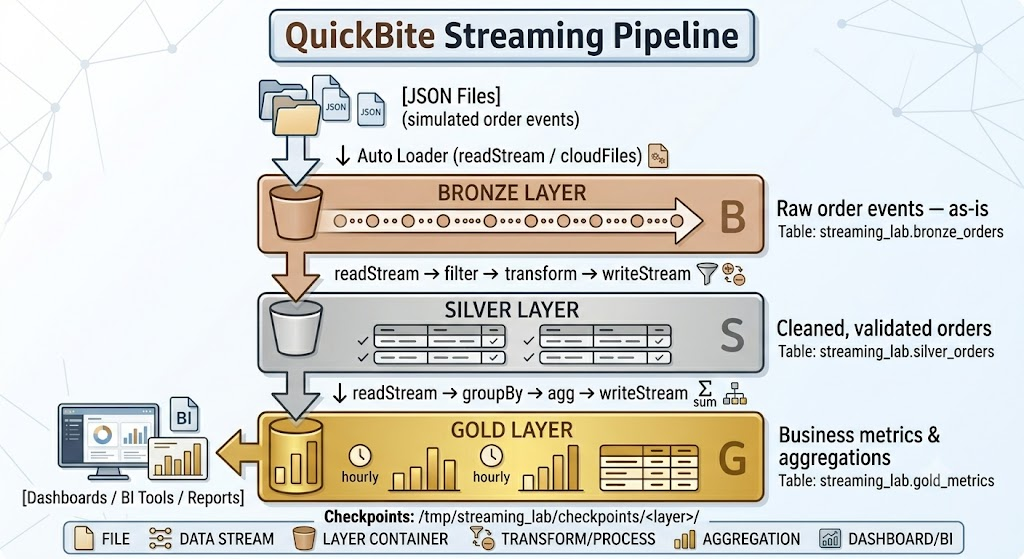

---
 
## Certification Tips Summary
 
### `readStream` vs `read`
 
> `spark.read` = batch (fixed data). `spark.readStream` = streaming (infinite table). The streaming DataFrame's `.isStreaming` property returns `True`. **Never** use `.show()`, `.count()`, `.sort()`, `.distinct()`, or `.limit()` directly on a streaming DataFrame.
 
---
 
### Output Modes
 
> - `append` = new rows only. Use for Bronze, Silver, and any non-aggregation query.
> - `complete` = full result rewritten. Use for `groupBy` + `agg` queries.
> - `update` = changed rows only. **Not supported for Delta file sinks**.
> - **Exam trap:** `complete` mode on a non-aggregation query throws an error.
 
---
 
### Checkpoints
 
> A checkpoint is **mandatory** for production streaming. It enables fault tolerance and exactly-once delivery. Each stream needs its **own unique checkpoint directory**. Deleting a checkpoint forces the stream to start from the beginning.
 
---
 
### Triggers
 
> - `processingTime="Xs"` = run continuously every X seconds (real-time).
> - `availableNow=True` = process all backlog, then stop (scheduled incremental).
> - `once=True` = deprecated; use `availableNow` instead.
> - **Exam question:** "Which trigger processes all available data without running indefinitely?" → `availableNow`.
 
---
 
### Medallion Architecture
 
> Bronze = raw (as-is). Silver = clean (validated, typed). Gold = aggregated (business metrics). Each layer is a separate streaming job with its own checkpoint. The exam frequently asks the **purpose of each layer** and which **output mode** is appropriate for each.
 
---
 
### Exactly-Once Semantics
 
> Requires: (1) replayable source (Delta/Auto Loader), (2) checkpoint, (3) idempotent sink (Delta). All three together. Missing the checkpoint → at-least-once (possible duplicates). Missing Delta as sink → depends on sink's idempotency.

---
## Common Interview Questions
 
**Q1: What is the difference between `spark.read` and `spark.readStream`?**
 
`spark.read` performs a one-time batch read of a complete, finite dataset. `spark.readStream` creates a streaming DataFrame that represents an infinite, continuously updated table. Operations on a streaming DataFrame are evaluated incrementally, trigger by trigger, rather than all at once.
 
---
 
**Q2: Why is a checkpoint required for Spark Structured Streaming?**
 
A checkpoint saves the stream's progress — specifically which source offsets have been read and which micro-batches have been committed — to durable storage. Without a checkpoint, a restarted stream would have no memory of what it already processed, leading to either reprocessing all data from the beginning (duplicates) or starting from the latest point (data loss).
 
---
 
**Q3: What is the difference between `append` and `complete` output modes?**
 
`append` writes only newly computed rows to the sink each trigger — rows already written are never touched. `complete` rewrites the entire result table each trigger. `append` is used for event-driven pipelines where rows are not updated. `complete` is required for stateful aggregations (groupBy + agg) where results change as more data arrives.
 
---
 
**Q4: What operations are NOT supported on a streaming DataFrame, and why?**
 
`sort()`, `count()`, `distinct()`, and `limit()` are not directly supported because they require seeing the entire dataset before producing results — which is impossible on an unbounded stream that never ends. The workaround is `foreachBatch`, which gives you a batch DataFrame for each micro-batch, allowing all batch operations.
 
---
 
**Q5: What is the Medallion Architecture and why is it used?**
 
Medallion Architecture organizes data into three layers: Bronze (raw, as-is), Silver (cleaned, validated), and Gold (aggregated, business-ready). It separates concerns — Bronze preserves raw data for auditability and reprocessing, Silver provides trusted data for most consumers, and Gold pre-computes expensive aggregations for fast analytics. It also makes debugging easier: if Silver logic was wrong, you can replay from Bronze without re-ingesting.
 
---
 
**Q6: How does exactly-once semantics work in Spark Structured Streaming with Delta Lake?**
 
Three components work together: (1) the source is **replayable** (Delta log or Auto Loader tracks files), so data can be re-read after failure; (2) the **checkpoint** records which batches were committed, so retries know exactly which data to reprocess; (3) Delta Lake writes are **idempotent** — if the same micro-batch is committed twice (due to retry), Delta uses its transaction log to detect and reject the duplicate commit.
 
---
 
**Q7: What is the difference between `trigger(once=True)` and `trigger(availableNow=True)`?**
 
Both process available data and stop. `once` uses exactly one micro-batch, which can be slow or memory-intensive for large backlogs. `availableNow` uses multiple micro-batches as needed, making it more efficient and reliable for large volumes. `once` is deprecated; `availableNow` is the modern replacement.
 
---
 
**Q8: Why is Delta Lake the preferred sink for Spark Structured Streaming on Databricks?**
 
Delta Lake provides: (1) ACID transactions ensuring safe concurrent writes, (2) the transaction log enabling efficient incremental reads downstream, (3) schema enforcement catching bad data at write time, (4) idempotent writes for exactly-once semantics, (5) time travel for reprocessing and debugging. Plain Parquet or CSV sinks lack ACID guarantees and idempotency, giving only at-least-once semantics.
 
---
 
**Q9: What is Auto Loader (`cloudFiles`) and when should you use it?**
 
Auto Loader is Databricks' optimized incremental file ingestion tool. It monitors a cloud storage directory, detects new files using a notification queue or directory listing, and processes only new files each trigger — without scanning all files. It also handles schema evolution and stores schema state in a `schemaLocation`. Use it whenever ingesting files from cloud storage into Bronze.
 
---
 
**Q10: What happens if two streaming queries share the same checkpoint location?**
 
They will conflict and likely throw errors or corrupt each other's state. Each streaming query must have its own **unique** checkpoint location. The checkpoint encodes the specific schema, source, and sink configuration of one particular query — sharing it between different queries is undefined behavior.
 
---
 
**Q11: How does streaming differ from batch when handling failures?**
 
Batch jobs typically fail and require a full re-run from the beginning (unless carefully partitioned). Streaming jobs use checkpoints to resume exactly from the last committed offset — only unprocessed data since the last checkpoint needs to be reprocessed. Combined with Delta's idempotent writes, this means no data loss and no duplicates, even after repeated failures.
 
---
 
**Q12: What is `foreachBatch` and when would you use it?**
 
`foreachBatch` is a `writeStream` option that calls a user-defined function with each micro-batch as a **regular batch DataFrame**. Use it when you need: (1) operations unsupported in streaming (sort, count, distinct), (2) writing to multiple sinks per batch, (3) complex merge/upsert logic (MERGE INTO) on Delta tables, or (4) custom deduplication within a batch.

---

## Final Review

### The Six Most Important Concepts
 
**1. Streaming = Infinite Table**
Spark Structured Streaming treats a stream as a table that grows forever. New rows arrive continuously. Queries run incrementally against only new rows, not the entire dataset.
 
**2. readStream / writeStream**
`spark.readStream` creates a streaming DataFrame. `writeStream` starts the stream. The query doesn't run until `.start()` or `.toTable()` is called. `awaitTermination()` blocks the driver until the stream stops.
 
**3. Checkpoints are Mandatory**
Every production stream needs a unique `checkpointLocation`. It saves offsets and commit state. Without it, the stream cannot recover from failure. Deleting it resets the stream to the beginning.
 
**4. Output Mode Must Match Query Type**
- Append: no aggregation, new rows only
- Complete: with aggregation (groupBy + agg), full rewrite each trigger
- Update: changed rows (not supported by Delta file sinks)
**5. Exactly-Once = Source + Checkpoint + Idempotent Sink**
All three are required. Delta Lake provides the idempotent sink. Auto Loader or Delta provides the replayable source. The checkpoint ties them together.
 
**6. Medallion Architecture**
Bronze → raw, Silver → clean, Gold → aggregated. Each is a separate stream with its own checkpoint. Bronze uses `append` mode. Silver uses `append` mode. Gold uses `complete` mode for aggregations.
 
### Quick Reference — Exam Cheat Sheet
 
```text
OPERATION              STREAMING?    WORKAROUND
─────────────────────────────────────────────────
filter()               ✅ Yes        —
withColumn()           ✅ Yes        —
select()               ✅ Yes        —
groupBy() + agg()      ✅ Yes        outputMode=complete
sort() / orderBy()     ❌ No         foreachBatch
count()                ❌ No         foreachBatch
distinct()             ❌ No         foreachBatch or watermark
limit()                ❌ No         foreachBatch
show()                 ❌ No         console sink
 
OUTPUT MODE            WHEN TO USE
────────────────────────────────────
append                 Non-aggregation queries
complete               Aggregation queries (groupBy)
update                 Changed rows only (no Delta file sink)
 
TRIGGER                BEHAVIOR
────────────────────────────────────
processingTime="Xs"    Run every X seconds, forever
availableNow=True      Drain backlog, then stop (modern)
once=True              One batch, stop (deprecated)
 
LAYER    PURPOSE              MODE
───────────────────────────────────
Bronze   Raw ingestion        append
Silver   Clean & validate     append
Gold     Aggregate            complete
```
 